# Prior-Conditioned Repetition Cue CRP

> Stratify ordinary forward transition lags by the prior recall's offset from repeated-item occurrences.


## Workflow

1. Load observed mixed-list data and the matched shuffled control.
2. Compute subject-level cue CRP arrays once and reuse them for all plots.
3. Plot the refined cue-offset by transition-lag surface, with access-to-repeater cells outlined.
4. Plot the transformed previous-offset by next-offset surface, where repeater access is the next-offset 0 row.
5. Plot access diagonal curves and selected offset-specific ordinary CRPs.
6. Run observed-vs-control and first-minus-second statistical tests.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from jaxcmr.analyses.repcuecrp import (
    _masked_cmap,
    _overlay_access_cells,
    _previous_next_surface,
    subject_rep_cue_crp,
    test_first_second_access_band_bias,
    test_first_second_access_bias,
    test_first_second_bias,
    test_rep_cue_access_band_vs_control,
    test_rep_cue_access_vs_control,
    test_rep_cue_crp_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure
from jaxcmr.plotting import plot_data, set_plot_labels
from jaxcmr.repetition import make_control_dataset

In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
min_lag = 4
max_lag = 5
max_offset = max_lag
size = 2
cue_offsets = [-5, -4, -3, -2, -1, 1, 2, 3, 4, 5]
cue_offsets_to_plot = [-2, -1, 1, 2]
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)

In [4]:
observed_crp = subject_rep_cue_crp(
    data, trial_mask, min_lag, max_lag, max_offset, size
)
control_crp = subject_rep_cue_crp(
    control_dataset, control_mask, min_lag, max_lag, max_offset, size
)

datasets = (observed_crp, control_crp)
sources = ("Mixed", "Control")
rep_labels = ("First", "Second")

lag_labels = np.arange(-max_lag, max_lag + 1)
cue_offset_labels = np.arange(-max_offset, max_offset + 1)
access_offset_labels = cue_offset_labels
heatmap_values = np.concatenate([observed_crp[np.isfinite(observed_crp)], control_crp[np.isfinite(control_crp)]])
heatmap_vmin = 0
heatmap_vmax = np.nanpercentile(heatmap_values, 95)


def access_diagonal(subject_crp):
    access = np.full((subject_crp.shape[0], subject_crp.shape[1], len(access_offset_labels)), np.nan)
    for offset_index, cue_offset in enumerate(access_offset_labels):
        if cue_offset == 0:
            continue
        lag_index = np.where(lag_labels == -cue_offset)[0]
        if lag_index.size:
            access[:, :, offset_index] = subject_crp[:, :, cue_offset + max_offset, lag_index[0]]
    return access

/var/folders/7n/m1dxq2r12b77t0c09mty9kn00000gn/T/ipykernel_78276/2740772640.py:5: RuntimeWarning: Mean of empty slice
  surface = np.nanmean(subject_crp[:, repetition_index], axis=0)


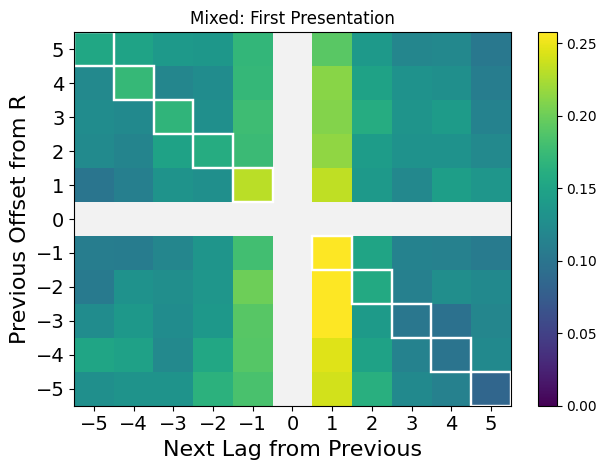

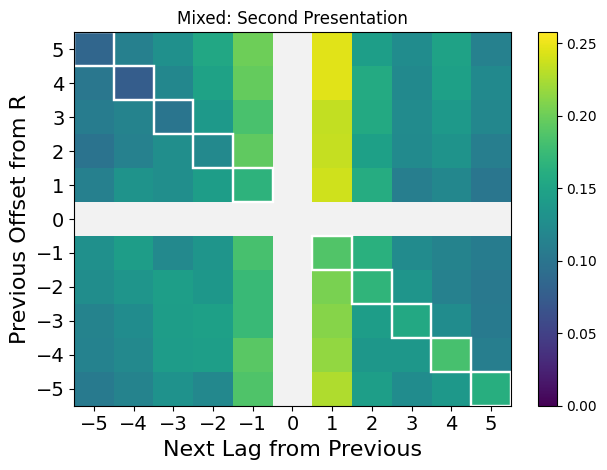

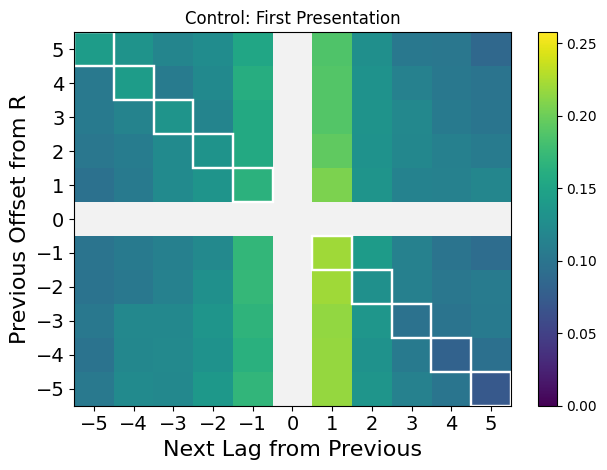

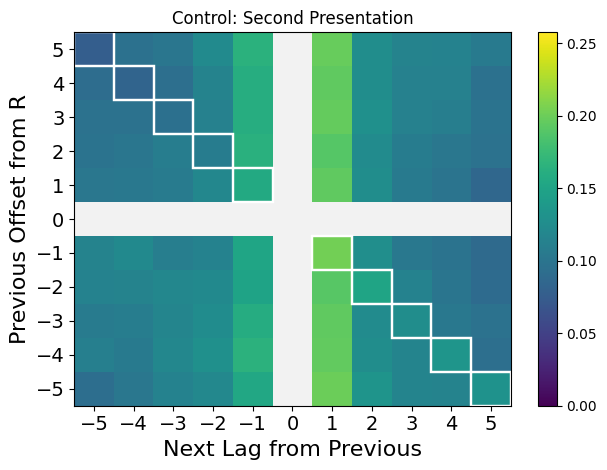

In [5]:
for source, subject_crp in zip(sources, datasets):
    for repetition_index, rep_label in enumerate(rep_labels):
        plt.figure()
        axis = plt.gca()
        surface = np.nanmean(subject_crp[:, repetition_index], axis=0)
        image = axis.imshow(
            np.ma.masked_invalid(surface),
            origin="lower",
            aspect="auto",
            cmap=_masked_cmap(),
            vmin=heatmap_vmin,
            vmax=heatmap_vmax,
            extent=[
                -max_lag - 0.5,
                max_lag + 0.5,
                -max_offset - 0.5,
                max_offset + 0.5,
            ],
        )
        axis.figure.colorbar(image, ax=axis)
        axis.set_xticks(lag_labels)
        axis.set_yticks(cue_offset_labels)
        axis.set_xlabel("Next Lag from Previous", fontsize=16)
        axis.set_ylabel("Previous Offset from R", fontsize=16)
        axis.tick_params(labelsize=14)
        _overlay_access_cells(axis, max_offset=max_offset, max_lag=max_lag)
        plt.title(f"{source}: {rep_label} Presentation")
        save_figure(
            figure_dir,
            figure_str,
            suffix=f"{source.lower()}_surface_{rep_label.lower()}",
        )

/var/folders/7n/m1dxq2r12b77t0c09mty9kn00000gn/T/ipykernel_78276/2718331832.py:8: RuntimeWarning: Mean of empty slice
  surface = np.nanmean(offset_surface[:, repetition_index], axis=0)


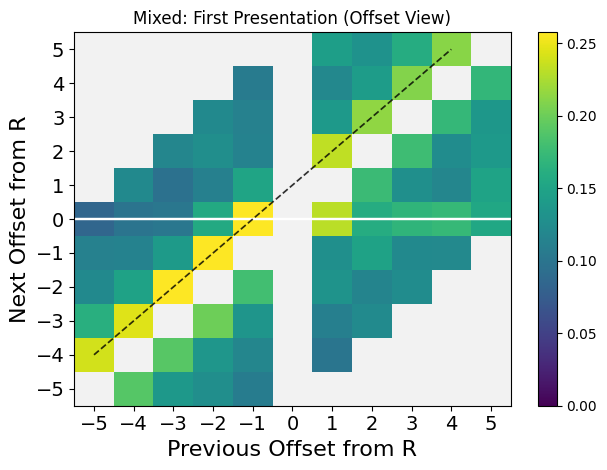

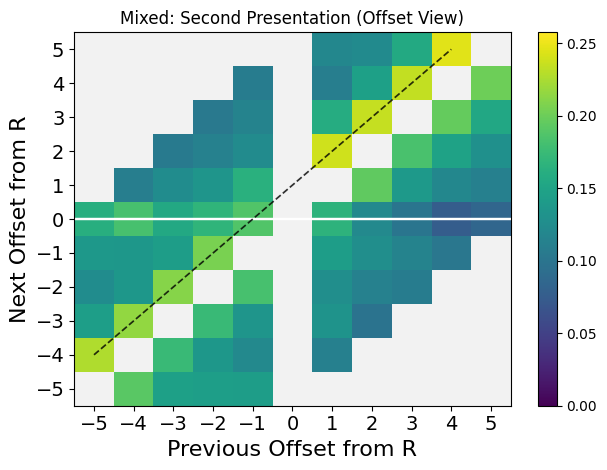

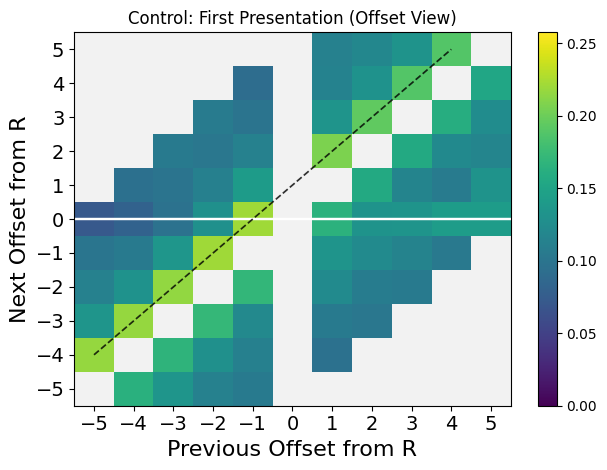

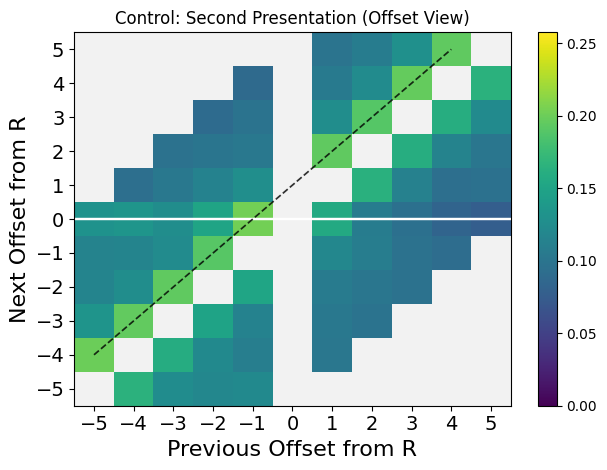

In [6]:
for source, subject_crp in zip(sources, datasets):
    _, offset_surface = _previous_next_surface(
        subject_crp, max_offset=max_offset, max_lag=max_lag
    )
    for repetition_index, rep_label in enumerate(rep_labels):
        plt.figure()
        axis = plt.gca()
        surface = np.nanmean(offset_surface[:, repetition_index], axis=0)
        image = axis.imshow(
            np.ma.masked_invalid(surface),
            origin="lower",
            aspect="auto",
            cmap=_masked_cmap(),
            vmin=heatmap_vmin,
            vmax=heatmap_vmax,
            extent=[
                -max_offset - 0.5,
                max_offset + 0.5,
                -max_offset - 0.5,
                max_offset + 0.5,
            ],
        )
        axis.figure.colorbar(image, ax=axis)
        axis.set_xticks(cue_offset_labels)
        axis.set_yticks(cue_offset_labels)
        axis.set_xlabel("Previous Offset from R", fontsize=16)
        axis.set_ylabel("Next Offset from R", fontsize=16)
        axis.tick_params(labelsize=14)
        axis.axhline(0, color="white", linewidth=1.75)
        x_values = cue_offset_labels
        y_values = cue_offset_labels + 1
        valid = (y_values >= -max_offset) & (y_values <= max_offset)
        axis.plot(
            x_values[valid],
            y_values[valid],
            linestyle="--",
            color="black",
            linewidth=1.25,
            alpha=0.8,
        )
        plt.title(f"{source}: {rep_label} Presentation (Offset View)")
        save_figure(
            figure_dir,
            figure_str,
            suffix=f"{source.lower()}_offset_surface_{rep_label.lower()}",
        )

/Users/jordangunn/workspace/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:365: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


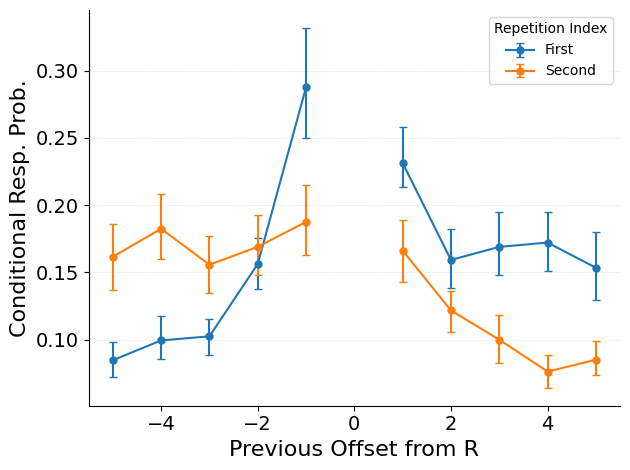

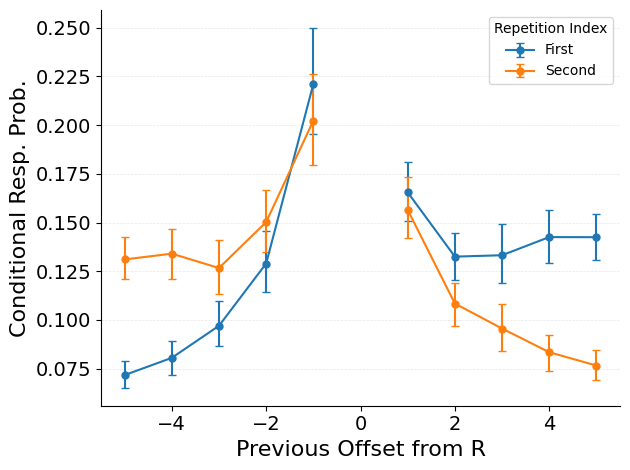

In [7]:
color_cycle = [each["color"] for each in plt.rcParams["axes.prop_cycle"]]

for source, subject_crp in zip(sources, datasets):
    plt.figure()
    axis = plt.gca()
    access_crp = access_diagonal(subject_crp)
    for repetition_index, rep_label in enumerate(rep_labels):
        plot_data(
            axis,
            access_offset_labels,
            access_crp[:, repetition_index, :],
            rep_label,
            color_cycle[repetition_index % len(color_cycle)],
            confidence_level=confidence_level,
        )
    set_plot_labels(axis, "Previous Offset from R", "Conditional Resp. Prob.", "Repetition Index")
    # plt.title(f"{source}: Access Diagonal")
    if ylim is not None:
        axis.set_ylim(ylim)
    save_figure(figure_dir, figure_str, suffix=f"{source.lower()}_access_diagonal")

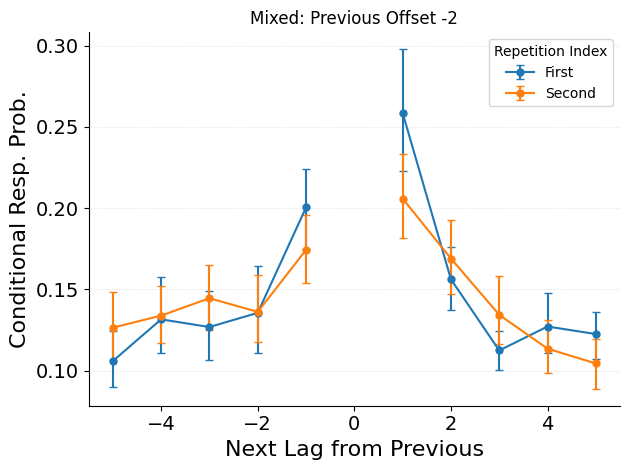

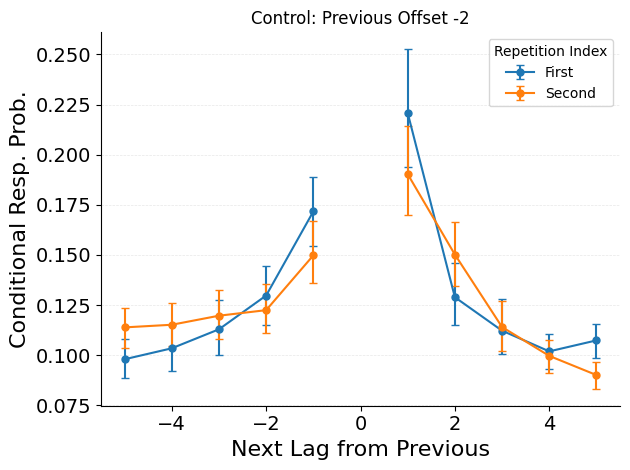

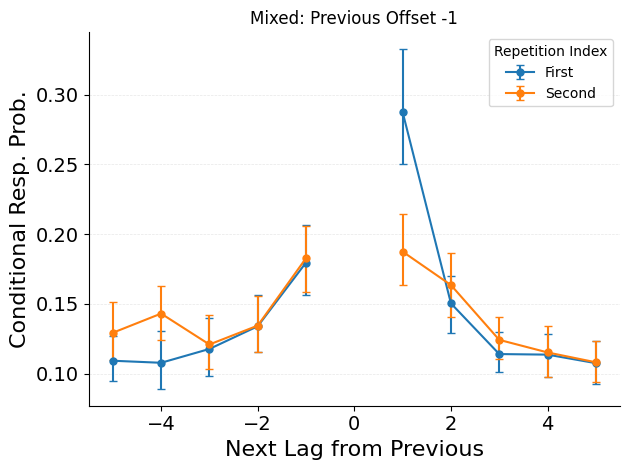

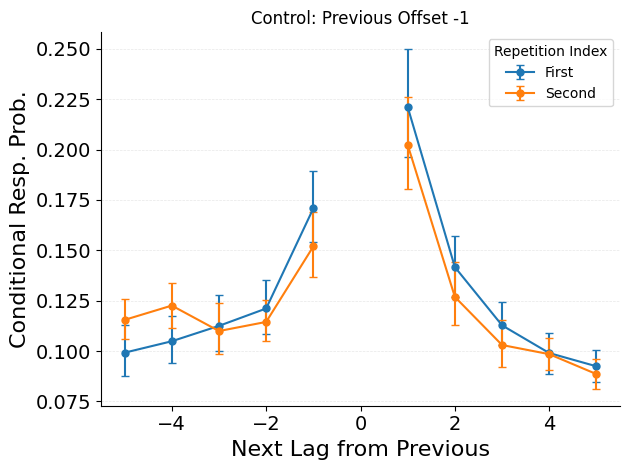

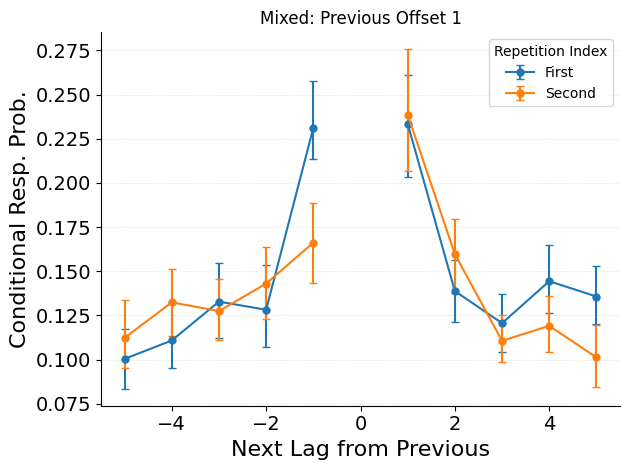

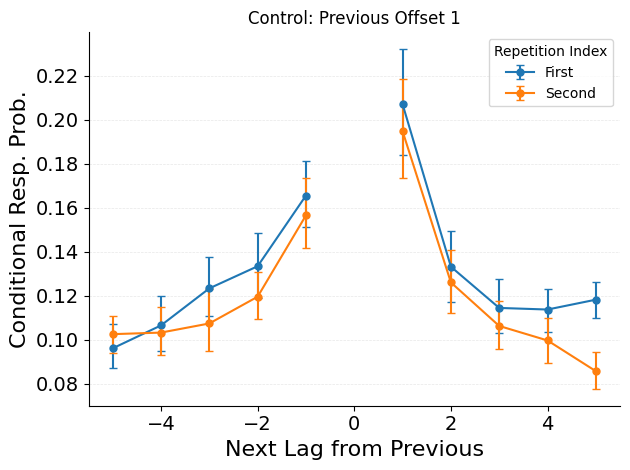

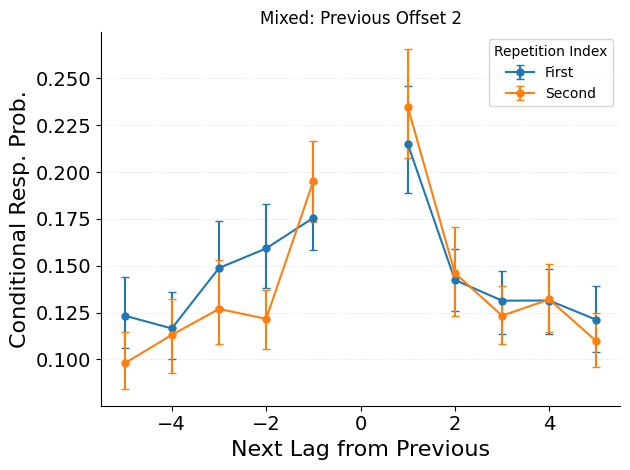

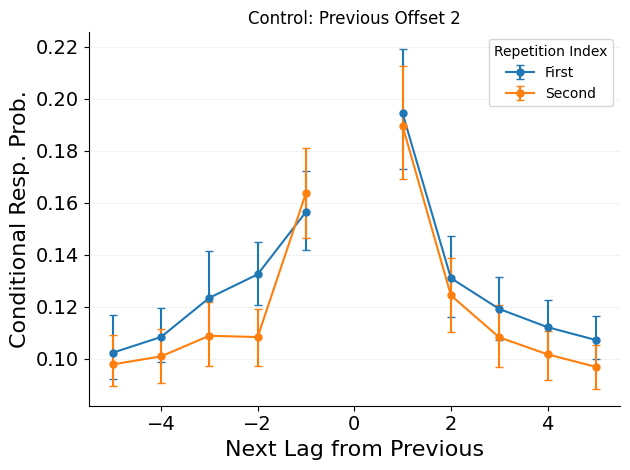

In [8]:
for cue_offset in cue_offsets_to_plot:
    for source, subject_crp in zip(sources, datasets):
        plt.figure()
        axis = plt.gca()
        offset_values = subject_crp[:, :, cue_offset + max_offset, :]
        for repetition_index, rep_label in enumerate(rep_labels):
            plot_data(
                axis,
                lag_labels,
                offset_values[:, repetition_index, :],
                rep_label,
                color_cycle[repetition_index % len(color_cycle)],
                confidence_level=confidence_level,
            )
        set_plot_labels(axis, "Next Lag from Previous", "Conditional Resp. Prob.", "Repetition Index")
        plt.title(f"{source}: Previous Offset {cue_offset}")
        if ylim is not None:
            axis.set_ylim(ylim)
        save_figure(figure_dir, figure_str, suffix=f"{source.lower()}_offset_{cue_offset}")

In [9]:
access_results = test_rep_cue_access_vs_control(
    observed_crp, control_crp, max_offset=max_offset, max_lag=max_lag
)
for label, result in access_results.items():
    print()
    print("="*60)
    print(f"Access Diagonal Tests: {label}")
    print("="*60)
    print(result)

access_bias_result = test_first_second_access_bias(
    observed_crp, control_crp, max_offset=max_offset, max_lag=max_lag
)
print()
print("="*70)
print("Test: First-Second Access Bias (Observed) vs First-Second Access Bias (Control)")
print("="*70)
print(access_bias_result)

access_band_results = test_rep_cue_access_band_vs_control(
    observed_crp,
    control_crp,
    cue_offsets=(-1, 1),
    max_offset=max_offset,
    max_lag=max_lag,
)
for label, result in access_band_results.items():
    print()
    print("="*60)
    print(f"Neighbor Access Band Tests: {label}")
    print("="*60)
    print(result)

access_band_bias_result = test_first_second_access_band_bias(
    observed_crp,
    control_crp,
    cue_offsets=(-1, 1),
    max_offset=max_offset,
    max_lag=max_lag,
)
print()
print("="*70)
print("Test: First-Second Neighbor Access Band Bias")
print("="*70)
print(access_band_bias_result)

for cue_offset in cue_offsets_to_plot:
    results = test_rep_cue_crp_vs_control(
        observed_crp,
        control_crp,
        cue_offset=cue_offset,
        max_offset=max_offset,
        max_lag=max_lag,
    )
    for label, result in results.items():
        print()
        print("="*60)
        print(f"Cue Offset {cue_offset} Tests: {label}")
        print("="*60)
        print(result)

    bias_result = test_first_second_bias(
        observed_crp,
        control_crp,
        cue_offset=cue_offset,
        max_offset=max_offset,
        max_lag=max_lag,
    )
    print()
    print("="*70)
    print(f"Test: First-Second Bias at Cue Offset {cue_offset}")
    print("="*70)
    print(bias_result)


Access Diagonal Tests: First Presentation
Offset |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
-------+----------------------+----------------------+------------
    -5 |    1.666     0.1048 |    236.0     0.2012 |     0.0130
    -4 |    2.285     0.0286 |    186.0     0.0341 |     0.0189
    -3 |    0.683     0.4992 |    277.0     0.5436 |     0.0055
    -2 |    2.870     0.0070 |    170.0     0.0166 |     0.0273
    -1 |    4.913     0.0000 |     69.0     0.0000 |     0.0664
     0 |      nan        nan |      nan        nan |        nan
     1 |    5.503     0.0000 |     54.0     0.0000 |     0.0658
     2 |    2.466     0.0189 |    203.0     0.0674 |     0.0268
     3 |    3.612     0.0010 |    130.0     0.0018 |     0.0357
     4 |    2.775     0.0089 |    164.0     0.0124 |     0.0296
     5 |    0.858     0.3971 |    295.0     0.7524 |     0.0110

Access Diagonal Tests: Second Presentation
Offset |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
-------+------

## Interpretation

The first surface plots show the original prior-conditioned CRP: previous offset is the prior recalled item's serial-position offset from a repeated-item occurrence, and next lag is the ordinary forward lag from that just-recalled item to the next recalled item. Outlined cells mark transitions in which the next recall is the repeated item.

The second surface plots transform the same values into previous-offset by next-offset coordinates. In this view, access to the repeated item is always the `next offset = 0` row, and ordinary +1 contiguity lies on the dashed `next = previous + 1` line.

The access-diagonal plot extracts cells where `next lag = -previous offset`. These are the transitions in which the next recall is the repeated item occurrence defining the offset. This diagonal is the focused repeated-item access measure while preserving the ordinary forward-CRP denominator.

The offset-specific CRP plots show ordinary transition-lag curves after prior recalls that were at selected offsets from first or second repeated-item presentations. Their x-axis is not lag from the repeater; it is lag from the just-recalled item.


## API Details

### Notebook parameters

- `mixed_trial_query`: selects repeated-item mixed lists.
- `control_trial_query`: selects pure-list trials used to build the shuffled control.
- `control_shuffles`: number of shuffled control blocks.
- `min_lag`: minimum spacing between repeated presentations.
- `max_offset`: maximum previous/next offset shown and tested.
- `max_lag`: maximum ordinary transition lag shown and tested.
- `cue_offsets_to_plot`: selected previous offsets for ordinary CRP curves.

### Analysis functions

- `subject_rep_cue_crp(...)` returns subject-level arrays with shape `(subjects, repetition_index, previous_offset, next_lag)`.
- `plot_rep_cue_crp_surface(...)` displays the previous-offset by next-lag surface and marks access-to-repeater cells.
- `plot_rep_cue_offset_surface(...)` displays the transformed previous-offset by next-offset surface.
- `plot_rep_cue_access_crp(...)` displays the diagonal `next lag = -previous offset`, with offset 0 left empty so the line breaks at the repeated item.
- `plot_rep_cue_crp(...)` displays an ordinary transition-lag CRP for one previous offset.
- `test_rep_cue_access_vs_control(...)` and `test_first_second_access_bias(...)` test the access diagonal.
- `test_rep_cue_crp_vs_control(...)` and `test_first_second_bias(...)` test offset-specific ordinary CRP curves.

Unlike target-conditioned access summaries, this is a forward prior-conditioned CRP. It conditions on a prior observed recall and asks what transition lags follow from that state.
